# Day 4 — HellaSwag and the Art of Testing Common Sense

*Why finishing a sentence correctly requires more than pattern matching — and how we measure it.*

**This file is the single source of truth.** The notebook (`hellaswag_lesson.ipynb`) is generated
from it cell by cell, and the blog (`lesson.html`) explains the same eight sections in the same
order. Run it either way:

```
python hellaswag_demo.py                       # small model (124 million parameters), 1,000 questions
python hellaswag_demo.py --model gpt2-xl       # the 1.5 billion parameter model (needs about 8 GB free)
python hellaswag_demo.py --limit 200           # quick run (a few minutes); fewer questions = a wobblier score
```

## The eight sections
| # | Section | The question it answers |
|---|---------|-------------------------|
| 1 | Anatomy of one question | What does a HellaSwag question actually look like? |
| 2 | The maths by hand | How can a model that only predicts the next word choose between four endings? |
| 3 | A real model takes the test | What score does a real model get, and how do the scoring rules differ? |
| 4 | Cheap tricks fail | Why can't you pass by counting words? |
| 5 | Adversarial Filtering in miniature | How was the test made hard on purpose? |
| 6 | What does 55% mean? | How do we read a score honestly? |
| 7 | Reading the mistakes | Where does the model go wrong? |
| 8 | What HellaSwag still misses | What is left untested? |

## Words you will meet (with an example each)
* **Benchmark** – a fixed exam for models. *Example: 10,042 multiple-choice questions, same for every model.*
* **Common sense** – everyday knowledge nobody writes down. *Example: a shingle you pull off a roof does not
  float away by itself; a person holding a rubik's cube is not removing roofing.*
* **Token** – a small chunk of text the model reads. *Example: "roofing" may become two tokens, "roof" and "ing".*
* **Probability** – a number from 0 to 1 saying how likely something is. *Example: 0.5 means "as likely as a coin landing heads".*
* **Conditional probability** – the probability of something *given what came before*.
  *Example: the probability of the word "pancakes" is higher after "She flipped the" than after "She parked the".*
* **Logarithm** – the "how many times did we multiply" number. We use the *natural* logarithm (base e ≈ 2.718).
  *Example: the natural logarithm of 1 is 0, of 0.5 is about −0.69, of 0.01 is about −4.6. Smaller probability → more negative.*
* **Parameter** – one adjustable number inside the model. *Example: "1.5 billion parameters" = 1.5 billion dials.*
* **Baseline** – the score you get with no skill. *Example: guessing among 4 options gives 25%.*
* **n-gram** – a run of *n* neighbouring words. *Example: "pulling up roofing" is a 3-gram (three-word run).*
* **Generator / discriminator** – a generator *makes* fake text; a discriminator *tries to tell fake from real*.
* **Adversarial Filtering** – keep only the fake endings that fool the discriminator.

In [1]:
# ---- Section 0: setup and settings -------------------------------------------------------------
import argparse
import math
import random
import re
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np

import matplotlib
if "ipykernel" not in sys.modules:          # plain script: draw to a file, no window
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

# These settings work both from the command line and inside the notebook.
parser = argparse.ArgumentParser(description="Day 4: HellaSwag walkthrough")
parser.add_argument("--model", default="gpt2",
                    help="gpt2 (124 million parameters) or gpt2-xl (1.5 billion parameters)")
parser.add_argument("--limit", type=int, default=1000, help="how many validation questions to score")
parser.add_argument("--filter_rounds", type=int, default=6, help="rounds of the toy Adversarial Filtering")
parser.add_argument("--seed", type=int, default=0, help="random seed so results repeat")
arguments, _unknown = parser.parse_known_args()

random.seed(arguments.seed)
np.random.seed(arguments.seed)
OUTPUT_DIRECTORY = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("model:", arguments.model, "| questions to score:", arguments.limit)

model: gpt2 | questions to score: 1000


## Section 1 — Anatomy of one question

HellaSwag stands for *Harder Endings, Longer contexts, and Low-shot Activities for Situations With
Adversarial Generations*. It is the grown-up sibling of an older test
called SWAG (*Situations With Adversarial Generations*).

Every question has:
1. an **activity label** – what is going on (for example "Roof shingle removal"),
2. a **context** – the start of a description, taken from video captions (ActivityNet) or how-to articles (wikiHow),
3. **four possible endings** – one is what really came next, three are machine-written impostors,
4. a **label** – the position (0, 1, 2 or 3) of the true ending.

The model's job: pick the true ending. Guessing gives 25%. People get about 95.6%.

In [2]:
EMBEDDED_EXAMPLE = {   # a real validation question, copied here so the lesson works offline
    "ind": 24,
    "activity_label": "Roof shingle removal",
    "ctx_a": "A man is sitting on a roof.",
    "ctx_b": "he",
    "endings": ["is using wrap to wrap a pair of skis.",
                "is ripping level tiles off.",
                "is holding a rubik's cube.",
                "starts pulling up roofing on a roof."],
    "label": "3",
    "source_id": "activitynet~v_-JhWjGDPHMY",
    "split_type": "indomain",
}


def load_split(split_name):
    """Download HellaSwag from Hugging Face. Returns None when offline."""
    try:
        from datasets import load_dataset
        return load_dataset("Rowan/hellaswag", split=split_name)
    except Exception as problem:                                   # offline, or package missing
        print(f"[note] could not load '{split_name}': {type(problem).__name__}")
        return None


validation_set = load_split("validation")
HAVE_DATA = validation_set is not None
worked_example = EMBEDDED_EXAMPLE                # always the same question, so lesson, notebook and blog agree
if HAVE_DATA:
    print("validation questions:", len(validation_set))
else:
    print("Offline mode: sections 4-8 need the dataset and will be skipped; sections 1-3 still run.")


def preprocess(text):
    """Tidy the raw text (the same recipe the standard evaluation harness uses)."""
    text = text.strip()
    text = text.replace(" [title]", ". ")           # wikiHow step markers
    text = re.sub(r"\[.*?\]", "", text)             # remove any other [bracketed] tags
    return text.replace("  ", " ")


def build_question(example):
    """Turn a raw row into (context text, list of ending texts, index of the true ending)."""
    context = example["ctx_a"] + " " + example["ctx_b"].capitalize()
    query = preprocess(example["activity_label"] + ": " + context)
    endings = [preprocess(ending) for ending in example["endings"]]
    return query, endings, int(example["label"])


query, endings, label = build_question(worked_example)
print("ACTIVITY :", worked_example["activity_label"])
print("CONTEXT  :", query)
for position, ending in enumerate(endings):
    marker = "  <-- true ending" if position == label else ""
    print(f"  ending {position}: {ending}{marker}")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


validation questions: 10042
ACTIVITY : Roof shingle removal
CONTEXT  : Roof shingle removal: A man is sitting on a roof. He
  ending 0: is using wrap to wrap a pair of skis.
  ending 1: is ripping level tiles off.
  ending 2: is holding a rubik's cube.
  ending 3: starts pulling up roofing on a roof.  <-- true ending


**Look closely.** Ending 0 (skis) and ending 2 (rubik's cube) are grammatical English, but *wrong for the
scene*. Ending 1 ("ripping level tiles off") is the tricky one: it is close to right, yet "level tiles" is an
odd phrase for roofing. Ending 3 fits the activity, the object (roof) and the action (pulling up). To choose it
you need a picture of the world, not just of grammar.

## Section 2 — The maths by hand: how a next-word predictor picks an ending

A language model such as GPT-2 (*Generative Pre-trained Transformer 2*) only knows one trick: given some text,
it gives a **probability for every possible next token**. It never sees "A, B, C, D" options. So how do we make
it answer a multiple-choice question?

**We ask: "How likely is it that this ending follows this context?" — once per ending — and pick the winner.**

### Step 1 — the chain rule
The probability of a whole ending is the *product* of the probability of each token given everything before it:

`probability(ending | context) = p(token 1 | context) × p(token 2 | context, token 1) × p(token 3 | ...) × ...`

### Step 2 — why we use logarithms
Multiplying many numbers below 1 makes tiny numbers. Computers run out of room ("underflow"):
the cell below shows 300 tokens of probability 0.001 becoming exactly zero. The natural logarithm turns
a product into a **sum**, which is safe:

`ln(a × b × c) = ln(a) + ln(b) + ln(c)`

So: **total log probability of an ending = the sum of the natural logarithm of each token's probability.**
Bigger (closer to zero) is better.

In [3]:
underflow = 1.0
for _ in range(300):
    underflow *= 0.001
print("Multiplying 300 probabilities of 0.001 gives:", underflow, "(computer says zero!)")
print("Adding their natural logarithms instead gives:", 300 * math.log(0.001), "(perfectly fine)")

# Illustrative (made-up) token probabilities to see the mechanics:
short_ending = [0.1, 0.1, 0.1]                    # 3 tokens, each fairly unlikely
long_ending = [0.2, 0.2, 0.2, 0.2, 0.2, 0.2]      # 6 tokens, each more likely


def total_log_probability(token_probabilities):
    return sum(math.log(p) for p in token_probabilities)


def average_log_probability(token_probabilities):
    return total_log_probability(token_probabilities) / len(token_probabilities)


for name, tokens in [("short ending", short_ending), ("long ending ", long_ending)]:
    print(f"{name}: total = {total_log_probability(tokens):7.3f} | average per token = {average_log_probability(tokens):6.3f}")

Multiplying 300 probabilities of 0.001 gives: 0.0 (computer says zero!)
Adding their natural logarithms instead gives: -2072.326583694641 (perfectly fine)
short ending: total =  -6.908 | average per token = -2.303
long ending : total =  -9.657 | average per token = -1.609


### Step 3 — the length trap
The long ending has *better tokens* (0.2 each versus 0.1 each) but a *worse total*, because every extra token
adds another negative number. **Adding up rewards short endings.** Two fixes are standard:

* **Average log probability per token** = total ÷ number of tokens.
* **Log probability per character** = total ÷ number of characters (this is what the popular evaluation
  harness calls "length-normalised accuracy"; it is the number people quote as "HellaSwag score").

### Step 4 — from scores to a choice (and to "confidence")
Pick the ending with the highest score. To see how *sure* the model is, use **softmax**: subtract the best
score, raise *e* (2.718...) to the power of each result, then divide by the total so the four numbers add to 100%.

`share of ending i = e^(score i − best score) ÷ sum over all endings of e^(score − best score)`

In [4]:
def softmax(scores):
    """Turn any list of scores into shares that add up to 1 (100%)."""
    best = max(scores)
    exponentials = [math.exp(score - best) for score in scores]
    total = sum(exponentials)
    return [value / total for value in exponentials]


illustrative_scores = [-3.1, -2.4, -3.0, -1.2]        # made-up "average log probability per token"
for position, share in enumerate(softmax(illustrative_scores)):
    print(f"ending {position}: score {illustrative_scores[position]:5.1f} -> share {share:6.1%}")
print("model picks ending", int(np.argmax(illustrative_scores)))

ending 0: score  -3.1 -> share   9.3%
ending 1: score  -2.4 -> share  18.6%
ending 2: score  -3.0 -> share  10.2%
ending 3: score  -1.2 -> share  61.9%
model picks ending 3


## Section 3 — A real model takes the test

Now replace the made-up numbers with a real model's. For each ending we feed `context + ending` to the model
and read off the probability it gave every ending token. (The very first token has nothing before it, so it is
not scored — the context always supplies plenty.)

In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"                                   # Apple Silicon graphics chip
else:
    device = "cpu"
data_type = torch.float16 if device != "cpu" else torch.float32
print("device:", device, "| numeric precision:", data_type)

tokenizer = AutoTokenizer.from_pretrained(arguments.model)
model = AutoModelForCausalLM.from_pretrained(arguments.model, dtype=data_type).to(device).eval()
print(f"loaded {arguments.model}: {sum(p.numel() for p in model.parameters()) / 1e6:.0f} million parameters")


@torch.no_grad()
def ending_token_log_probabilities(context, ending):
    """Return [(token text, natural-log probability), ...] for every token of `ending`."""
    context_ids = tokenizer.encode(context)
    full_ids = tokenizer.encode(context + " " + ending)
    if full_ids[:len(context_ids)] != context_ids:            # rare tokenisation quirk: fall back
        context_ids = full_ids[:max(1, len(full_ids) - len(tokenizer.encode(" " + ending)))]
    full_ids = full_ids[-1024:]                              # the model's maximum reading length
    ending_length = len(full_ids) - len(context_ids)
    ids = torch.tensor([full_ids], device=device)
    logits = model(ids).logits[0].float()                    # shape: (positions, vocabulary)
    log_probabilities = torch.log_softmax(logits, dim=-1)
    results = []
    for position in range(len(full_ids) - ending_length, len(full_ids)):
        token_id = full_ids[position]
        # the prediction for position p is made at position p-1
        results.append((tokenizer.decode([token_id]), log_probabilities[position - 1, token_id].item()))
    return results


def scores_for_question(context, endings):
    """Three scoring rules for each ending."""
    rows = []
    for ending in endings:
        tokens = ending_token_log_probabilities(context, ending)
        total = sum(value for _, value in tokens)
        rows.append({
            "tokens": tokens,
            "total": total,                                   # sum of log probabilities
            "per_token": total / len(tokens),                 # average per token
            "per_character": total / len(ending),             # divided by characters
        })
    return rows


rows = scores_for_question(query, endings)
print(f"\nContext: {query}\n")
print(f"{'#':>2} {'tokens':>6} {'total':>8} {'per token':>10} {'per char':>9}  ending")
for position, row in enumerate(rows):
    print(f"{position:>2} {len(row['tokens']):>6} {row['total']:>8.2f} {row['per_token']:>10.3f} "
          f"{row['per_character']:>9.3f}  {endings[position]}")
for rule in ["total", "per_token", "per_character"]:
    chosen = int(np.argmax([row[rule] for row in rows]))
    print(f"rule '{rule}' picks ending {chosen} -> {'CORRECT' if chosen == label else 'wrong'}")

device: cpu | numeric precision: torch.float32


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10016.89it/s]

loaded gpt2: 124 million parameters



Context: Roof shingle removal: A man is sitting on a roof. He

 # tokens    total  per token  per char  ending
 0     11   -42.18     -3.834    -1.140  is using wrap to wrap a pair of skis.
 1      6   -32.84     -5.473    -1.216  is ripping level tiles off.
 2      8   -24.56     -3.070    -0.945  is holding a rubik's cube.
 3      9   -33.58     -3.731    -0.933  starts pulling up roofing on a roof.
rule 'total' picks ending 2 -> wrong
rule 'per_token' picks ending 2 -> wrong
rule 'per_character' picks ending 3 -> CORRECT


Peek inside the winning ending, token by token. A token with probability near 1 (log probability near 0) was
"expected"; a very negative one was a surprise. Wrong endings usually contain a few big surprises.

In [6]:
print("Token-by-token for the TRUE ending:")
for token_text, log_probability in rows[label]["tokens"]:
    print(f"  {token_text!r:>14}  ln-probability {log_probability:7.3f}  (probability {math.exp(log_probability):.4f})")

Token-by-token for the TRUE ending:
       ' starts'  ln-probability  -5.315  (probability 0.0049)
      ' pulling'  ln-probability  -4.172  (probability 0.0154)
           ' up'  ln-probability  -3.052  (probability 0.0473)
         ' roof'  ln-probability  -7.861  (probability 0.0004)
           'ing'  ln-probability  -3.042  (probability 0.0477)
           ' on'  ln-probability  -3.728  (probability 0.0240)
            ' a'  ln-probability  -2.131  (probability 0.1187)
         ' roof'  ln-probability  -2.912  (probability 0.0544)
             '.'  ln-probability  -1.370  (probability 0.2540)


### Scoring a whole batch of questions
One question proves nothing. We score a random sample of validation questions and count how often each
rule picks the true ending. **Accuracy = correct answers ÷ questions asked.**

**Margin of error.** With *n* questions and accuracy *p*, the typical wobble (95% confidence) is
`1.96 × square root of ( p × (1 − p) ÷ n )`. With 200 questions and 40% accuracy that is about ±6.8 points, and with 1,000
questions about ±3.0 — so small runs are only rough.

In [7]:
def margin_of_error(accuracy, number_of_questions):
    return 1.96 * math.sqrt(accuracy * (1 - accuracy) / number_of_questions)


records = []
if HAVE_DATA:
    sample_indices = random.Random(arguments.seed).sample(range(len(validation_set)),
                                                          min(arguments.limit, len(validation_set)))
    for counter, index in enumerate(sample_indices, start=1):
        example = validation_set[index]
        context, candidate_endings, true_label = build_question(example)
        scored = scores_for_question(context, candidate_endings)
        records.append({
            "index": index, "example": example, "context": context, "endings": candidate_endings,
            "label": true_label,
            **{f"pick_{rule}": int(np.argmax([row[rule] for row in scored]))
               for rule in ["total", "per_token", "per_character"]},
        })
        if counter % 50 == 0:
            print(f"  scored {counter}/{len(sample_indices)}")

    accuracies = {}
    print(f"\nModel: {arguments.model}   questions: {len(records)}   random guessing: 25.0%")
    for rule, nice_name in [("total", "add up log probabilities        "),
                            ("per_token", "average per token               "),
                            ("per_character", "per character (harness standard)")]:
        accuracy = np.mean([r[f"pick_{rule}"] == r["label"] for r in records])
        accuracies[rule] = accuracy
        print(f"  {nice_name}: {accuracy:6.1%}  ± {margin_of_error(accuracy, len(records)):.1%}")
else:
    print("Skipped: dataset not available offline.")

  scored 50/1000


  scored 100/1000


  scored 150/1000


  scored 200/1000


  scored 250/1000


...

  scored 800/1000


  scored 850/1000


  scored 900/1000


  scored 950/1000


  scored 1000/1000

Model: gpt2   questions: 1000   random guessing: 25.0%
  add up log probabilities        :  26.6%  ± 2.7%
  average per token               :  30.4%  ± 2.9%
  per character (harness standard):  30.3%  ± 2.8%


**What to notice.** Adding up (rule 1) scores lowest because of the length trap from Section 2: it favours
short endings whether or not they are right. The two normalised rules land within a fraction of a point of each
other on a large sample. *Same model, same questions, different score* — so a HellaSwag number is meaningless
unless you know **which scoring rule** produced it. (On our single worked question the rules disagree even
more sharply — see above.)

## Section 4 — Why simple tricks fail (the point of "adversarial")

If a test can be passed without the skill it claims to measure, it measures something else. Three cheap
tricks a student might try *without reading the context at all, or without understanding it*:

1. **Longest ending wins.** (Real endings often ramble; fake ones are sometimes clipped.)
2. **Word overlap.** Pick the ending sharing the most words with the context. *Example: context mentions
   "roof", ending mentions "roof" → looks right.*
3. **Ending-only n-gram classifier.** Train a tiny program on thousands of examples to recognise
   "real-sounding" endings *from the ending alone*, using single words and two-word runs (2-grams).

To see what the adversarial construction achieved, we also build an **easy version** of the exam where the three
wrong endings are the true endings of *random other questions* (a "roof" question might get a "baking" ending).
Word overlap should shine there.

In [8]:
if HAVE_DATA:
    from sklearn.feature_extraction.text import HashingVectorizer
    from sklearn.linear_model import LogisticRegression

    train_set = load_split("train")
    training_questions = [build_question(train_set[i]) for i in range(4000)]
    test_questions = [build_question(validation_set[i]) for i in range(2000)]


    def trick_accuracy(picker, questions):
        return float(np.mean([picker(context, options) == true_label for context, options, true_label in questions]))


    def words_of(text):
        return set(re.findall(r"[a-z']+", text.lower()))


    def pick_longest(context, options):
        return int(np.argmax([len(option) for option in options]))


    def pick_by_overlap(context, options):
        context_words = words_of(context)
        return int(np.argmax([len(context_words & words_of(o)) / (len(words_of(o)) + 1) for o in options]))


    # trick 3: a logistic-regression program (a simple yes/no scorer) on word 1-grams and 2-grams of the ending only
    vectoriser = HashingVectorizer(ngram_range=(1, 2), n_features=2 ** 18, alternate_sign=False)
    texts = [o for _, options, _ in training_questions for o in options]
    targets = [int(i == true_label) for _, _, true_label in training_questions for i in range(4)]
    ending_only_classifier = LogisticRegression(max_iter=300).fit(vectoriser.transform(texts), targets)


    def pick_by_ending_only(context, options):
        return int(np.argmax(ending_only_classifier.decision_function(vectoriser.transform(options))))


    # the easy version: wrong endings borrowed from other questions
    true_endings = [options[true_label] for _, options, true_label in test_questions]
    easy_questions = []
    shuffler = random.Random(1)
    for i, (context, options, true_label) in enumerate(test_questions):
        borrowed = shuffler.sample([e for j, e in enumerate(true_endings) if j != i], 3)
        mixed = borrowed + [options[true_label]]
        shuffler.shuffle(mixed)
        easy_questions.append((context, mixed, mixed.index(options[true_label])))

    print(f"{'trick':<38} {'easy exam':>10} {'real HellaSwag':>15}   (random guessing = 25%)")
    for name, picker in [("longest ending", pick_longest), ("word overlap with context", pick_by_overlap)]:
        print(f"{name:<38} {trick_accuracy(picker, easy_questions):>10.1%} {trick_accuracy(picker, test_questions):>15.1%}")
    print(f"{'ending-only n-gram classifier':<38} {'—':>10} {trick_accuracy(pick_by_ending_only, test_questions):>15.1%}")
else:
    print("Skipped: dataset not available offline.")

trick                                   easy exam  real HellaSwag   (random guessing = 25%)
longest ending                              25.7%           22.4%
word overlap with context                   66.5%           34.2%


ending-only n-gram classifier                   —           31.3%


**Reading the table.** Word overlap jumps far above 25% on the easy exam (topic words give the game away) but
collapses on real HellaSwag. The wrong endings were *chosen* to talk about the same topic, so the shortcut has
nothing to grab. That is what "adversarial" buys: the shortcut stops working.

## Section 5 — Adversarial Filtering in miniature

How were those wrong endings chosen? By **Adversarial Filtering**, a cat-and-mouse game:

1. A **generator** (a text-writing model) produces a big pool of candidate wrong endings.
2. A **discriminator** (a classifier) learns to tell real endings from generated ones.
3. Keep the candidates the discriminator *believes are real* (they fooled it) and throw away the obvious fakes.
4. Retrain the discriminator on the new, harder set. Repeat.

After enough rounds even a well-trained discriminator scores near guessing on the surviving impostors — and
because the discriminator looks at surface patterns, so do the cheap tricks from Section 4.

**Honest disclaimer:** this is a *toy*. Our generator is a **bigram Markov chain** (it picks each next word only
by looking at the previous word), the discriminator is the same simple classifier as before, and the wrong endings
ignore the context. The real dataset used far stronger models. The mechanism, however, is the same — and you can
watch the cheat-sheet stop working.

Examples of generated fake endings:
  - are shaky remodeling the completes boot reading a man
  - heats up remove sit lobbed size thousands of pose,
  - speeds up in the sterile towel dry hair.
  - , she calls a screenshots of the rough waters

round  discriminator accuracy on unseen questions (25% = fooled completely)


    0   62.5%  <- before any filtering


    1   31.0%


    2   30.8%


    3   29.5%


    4   28.4%


    5   29.8%


    6   28.1%


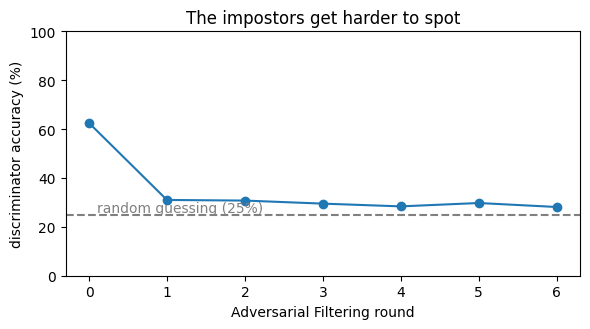

In [9]:
if HAVE_DATA:
    pre_train = load_split("train") if "train_set" not in globals() else train_set
    real_endings = [preprocess(pre_train[i]["endings"][int(pre_train[i]["label"])]) for i in range(6000)]

    # --- the generator: for each word, remember which words followed it in real endings
    next_words = defaultdict(list)
    first_words = []
    for text in real_endings:
        words = text.split()
        if not words:
            continue
        first_words.append(words[0])
        for current, following in zip(words, words[1:] + ["<END>"]):
            next_words[current].append(following)
    vocabulary = list(next_words.keys())
    generator_random = random.Random(arguments.seed)


    def generate_ending(target_length):
        """Write a fake ending. A random 'noise' level makes some fakes sloppy, some fluent."""
        noise = generator_random.random() * 0.6
        words = [generator_random.choice(first_words)]
        while len(words) < target_length:
            if generator_random.random() < noise:
                following = generator_random.choice(vocabulary)                  # sloppy: any word
            else:
                following = generator_random.choice(next_words[words[-1]])       # fluent: a plausible next word
            if following == "<END>":
                break
            words.append(following)
        return " ".join(words)


    print("Examples of generated fake endings:")
    for _ in range(4):
        print("  -", generate_ending(9))

    # --- the filtering game
    number_for_training, number_for_testing, pool_size = 2000, 800, 15
    real = real_endings[:number_for_training + number_for_testing]
    lengths = [max(4, len(text.split())) for text in real]
    vectoriser = HashingVectorizer(ngram_range=(1, 2), n_features=2 ** 16, alternate_sign=False)


    def new_pool():
        return [[generate_ending(lengths[i]) for _ in range(pool_size)] for i in range(len(real))]


    def train_discriminator(question_ids, history):
        texts = [real[i] for i in question_ids] + [d for i in question_ids for d in history[i]]
        targets = [1] * len(question_ids) + [0] * sum(len(history[i]) for i in question_ids)
        return LogisticRegression(max_iter=300, C=0.3).fit(vectoriser.transform(texts), targets)


    def four_way_accuracy(discriminator, question_ids, distractors):
        correct = 0
        for i in question_ids:
            scores = discriminator.decision_function(vectoriser.transform([real[i]] + distractors[i]))
            correct += int(np.argmax(scores) == 0)          # index 0 is the real ending
        return correct / len(question_ids)


    train_ids = list(range(number_for_training))
    test_ids = list(range(number_for_training, number_for_training + number_for_testing))
    pool = new_pool()
    chosen = {i: generator_random.sample(pool[i], 3) for i in range(len(real))}      # round 0: random fakes
    history = {i: list(chosen[i]) for i in range(len(real))}                          # every fake seen so far
    filter_curve = []
    print(f"\n{'round':>5}  discriminator accuracy on unseen questions (25% = fooled completely)")
    for round_number in range(arguments.filter_rounds + 1):
        discriminator = train_discriminator(train_ids, history)
        accuracy = four_way_accuracy(discriminator, test_ids, chosen)
        filter_curve.append(accuracy)
        label_text = "  <- before any filtering" if round_number == 0 else ""
        print(f"{round_number:>5}  {accuracy:6.1%}{label_text}")
        # keep the 3 candidates that look MOST real to this discriminator; then brew a fresh pool
        for i in range(len(real)):
            candidate_scores = discriminator.decision_function(vectoriser.transform(pool[i]))
            chosen[i] = [pool[i][j] for j in np.argsort(-candidate_scores)[:3]]
            history[i] += chosen[i]
        pool = new_pool()

    plt.figure(figsize=(6, 3.4))
    plt.plot(range(len(filter_curve)), [100 * a for a in filter_curve], marker="o")
    plt.axhline(25, linestyle="--", color="grey")
    plt.text(0.1, 26, "random guessing (25%)", color="grey")
    plt.xlabel("Adversarial Filtering round")
    plt.ylabel("discriminator accuracy (%)")
    plt.title("The impostors get harder to spot")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIRECTORY / "adversarial_filtering_curve.png", dpi=130)
    plt.show()
else:
    print("Skipped: dataset not available offline.")

## Section 6 — What does "55% on a 1.5 billion parameter model" actually tell us?

Turn the headline number into plain statements.

* **Distance from guessing.** Guessing = 25%. Humans = 95.6% (reported by the HellaSwag authors).
  Fraction of the gap closed = (55 − 25) ÷ (95.6 − 25) = 30 ÷ 70.6 ≈ **42%**.
* **Mistakes.** 55% correct means **45 wrong answers in every 100**.
* **Measurement wobble.** The validation set has 10,042 questions, so the margin of error is
  1.96 × square root of (0.55 × 0.45 ÷ 10,042) ≈ **±1.0 point**. A 55% model and a 56% model are practically tied.
* **Which scoring rule?** From Section 3: the same model can land several points apart depending on the rule.
* **Size context.** Roughly: the 124-million-parameter GPT-2 lands near 30%, the 1.5-billion-parameter GPT-2
  near 50%, and today's largest models above 90%. So 55% at 1.5 billion is *reasonable and unspectacular* — it
  says the model learned real regularities about everyday situations, but is still wrong nearly half the time.

(Reference points quoted from published papers/evaluation runs; treat them as approximate and re-check with the
Day 2 evaluation harness if you need exact digits.)

gap closed toward humans : 42.5%
wrong answers per 100    : 45
margin of error (10,042 questions): ±0.97 points


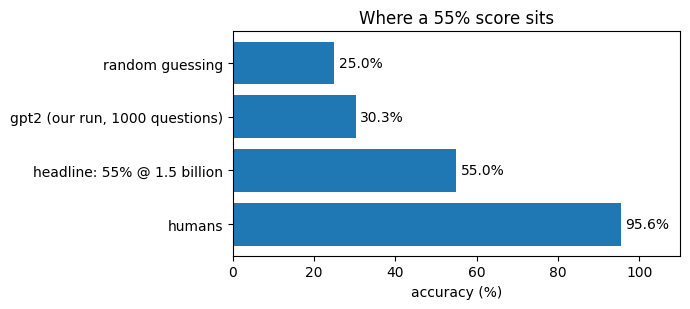

In [10]:
random_guess, human = 25.0, 95.6
headline = 55.0
gap_closed = (headline - random_guess) / (human - random_guess)
wobble = 1.96 * math.sqrt((headline / 100) * (1 - headline / 100) / 10042) * 100
print(f"gap closed toward humans : {gap_closed:.1%}")
print(f"wrong answers per 100    : {100 - headline:.0f}")
print(f"margin of error (10,042 questions): ±{wobble:.2f} points")

bars = [("random guessing", random_guess)]
if records:
    bars.append((f"{arguments.model} (our run, {len(records)} questions)", 100 * accuracies["per_character"]))
bars += [("headline: 55% @ 1.5 billion", headline), ("humans", human)]
plt.figure(figsize=(7, 3.2))
plt.barh([name for name, _ in bars][::-1], [value for _, value in bars][::-1])
for y_position, (_, value) in enumerate(bars[::-1]):
    plt.text(value + 1, y_position, f"{value:.1f}%", va="center")
plt.xlim(0, 110)
plt.xlabel("accuracy (%)")
plt.title("Where a 55% score sits")
plt.tight_layout()
plt.savefig(OUTPUT_DIRECTORY / "score_context.png", dpi=130)
plt.show()

### Why common sense is harder for models than facts

* **Facts get written down; common sense does not.** Encyclopaedias say "Paris is the capital of France" —
  many times, in many places. Nobody writes "a wet towel is heavier than a dry one" or "if you pull the plug the
  bath drains". Researchers call this **reporting bias**: text describes the *remarkable*, not the *obvious*.
  A model that learns from text sees the obvious only indirectly.
* **Facts have one anchor; common sense needs a simulation.** "Capital of France" is a lookup. "What happens next
  after the man loosens a shingle?" needs an imagined mini-world — objects, gravity, intent, what people usually do.
* **Facts can be checked by matching; common sense is judged by plausibility.** Several wrong endings can be
  grammatical and even topical; only one fits the physical and social scene.

## Section 7 — Reading the mistakes
Numbers hide the story. Here are questions where the model chose wrongly.

In [11]:
if records:
    wrong = [r for r in records if r["pick_per_character"] != r["label"]]
    print(f"{len(wrong)} of {len(records)} questions were answered wrongly. Three examples:\n")
    for record in wrong[:3]:
        print("CONTEXT :", record["context"])
        print("MODEL   :", record["endings"][record["pick_per_character"]])
        print("TRUTH   :", record["endings"][record["label"]])
        print()
else:
    print("Skipped: no scored questions.")

697 of 1000 questions were answered wrongly. Three examples:

CONTEXT : Home and Garden: How to choose a solar inverter. Learn about the commonly used solar inverters. Generally speaking, there are three major types of solar inverters on the market, including grid-tie, off-grid and hybrid inverters. Grid-tie inverter: it functions to convert dc to ac, with an ability to synchronize to interface with a utility line.
MODEL   : This works by controlling how much electricity there is coming into your tank. It is available in multiplier mode, as described below.
TRUTH   : This inverter is designed to transmit your unused electricity to the grid and has no battery. Mttp technology may be equipped in its input circuitry.

CONTEXT : Washing hands: A man is seen wearing scrubs and standing in front of a sink. The man
MODEL   : then gets down on his knee and begins washing dishes.
TRUTH   : washes his hands and turns to face the camera.

CONTEXT : Personal Care and Style: How to love your dark s

## Section 8 — What HellaSwag still misses

1. **Narrow slice of common sense.** Mostly everyday physical activities (sports, chores, cooking, how-to steps).
   Social reasoning ("why is she upset?"), cause and effect over long stories, numbers, time, and counterfactuals
   ("what if the roof were wet?") are barely touched.
2. **Multiple choice is not generation.** A model that can *rank* four endings may still *write* nonsense; the
   test never asks it to produce anything.
3. **Surface-level artefacts remain.** The impostors came from particular generators. A model trained on similar
   machine text may spot their fingerprints rather than understand the scene.
4. **Label noise and ambiguity.** Some questions have two defensible endings or an odd "true" one, which caps the
   score below 100% and rewards matching the *original writer's* style.
5. **Saturation.** Top models are now close to human level, so the test cannot separate the best from the very best.
6. **Possible contamination.** HellaSwag has been public since 2019; text resembling it may sit in a model's
   training data, inflating scores.
7. **Only English, only two source types** (video captions and wikiHow), and a single **scoring convention**
   that changes results (Section 3).
8. **A score is not an explanation.** Passing tells us the model picked well, not *why*.

The last cell checks one of these claims on your own run: does accuracy differ between the two text sources
(video captions versus wikiHow articles), and between "in-domain" and "zero-shot" (activities the training
set never showed)?

In [12]:
if records:
    def group_accuracy(key_function):
        groups = defaultdict(list)
        for record in records:
            groups[key_function(record)].append(record["pick_per_character"] == record["label"])
        return {name: (np.mean(values), len(values)) for name, values in groups.items()}

    print("By text source:")
    for name, (accuracy, count) in sorted(group_accuracy(lambda r: r["example"]["source_id"].split("~")[0]).items()):
        print(f"  {name:<12} accuracy {accuracy:6.1%}   (n = {count})")
    print("By activity novelty:")
    for name, (accuracy, count) in sorted(group_accuracy(lambda r: r["example"]["split_type"]).items()):
        print(f"  {name:<12} accuracy {accuracy:6.1%}   (n = {count})")
    print("\nSmall groups wobble a lot — raise --limit to 2000 or more for a stable comparison.")
else:
    print("Skipped: no scored questions.")

By text source:
  activitynet  accuracy  39.5%   (n = 334)
  wikihow      accuracy  25.7%   (n = 666)
By activity novelty:
  indomain     accuracy  30.3%   (n = 492)
  zeroshot     accuracy  30.3%   (n = 508)

Small groups wobble a lot — raise --limit to 2000 or more for a stable comparison.


## Recap
* HellaSwag = pick the true ending among four; guessing scores 25%, humans about 95.6%.
* A next-word model answers by comparing the probability of each ending — using **sums of logarithms** to stay
  numerically safe, and **length normalisation** to stay fair.
* The wrong endings are machine-written and **adversarially filtered**, so word-counting shortcuts fail.
* 55% at 1.5 billion parameters: real skill, far from human, and only meaningful once you know the scoring rule.
* Common sense is hard because it is *unwritten*, and HellaSwag covers only a slice of it.